# Group 7 — Science Communication Channels and Public Trust: Analysis Notebook

Rendered companion to the canonical analysis script; all outputs were produced by executing this notebook top-to-bottom against the full TISP dataset (N = 71,922 respondents, 68 countries).

Canonical script version: [`code/analysis.py`](../code/analysis.py)

In [1]:
import os, sys

# Resolve repo root so relative paths (data/, figures/, code/) work
# regardless of whether Jupyter was launched from the repo root or from notebooks/
_cwd = os.getcwd()
_repo_root = _cwd if os.path.isdir(os.path.join(_cwd, 'code')) else os.path.dirname(_cwd)
os.chdir(_repo_root)
sys.path.insert(0, os.path.join(_repo_root, 'code'))

from analysis import load, multilevel_model, sem_mediation, choropleth, anova_by_channel

In [2]:
df = load('data/raw/ds_main.csv')
print()
print('Dataset shape :', df.shape)
print('Countries     :', df['country'].nunique())

Total rows loaded: 71922
Analytic sample (non-missing trust/comm_freq/knowledge): 71883
Countries represented: 68

Dataset shape : (71883, 7)
Countries     : 68


## 1. Multi-level Model + ICC

Mixed-effects model with random intercepts by country. ICC quantifies the proportion of trust variance attributable to country-level factors.

In [3]:
result, icc = multilevel_model(df)


=== Multi-level model (trust ~ comm_freq + knowledge, random intercept: country) ===
          Mixed Linear Model Regression Results
Model:            MixedLM Dependent Variable: trust      
No. Observations: 71883   Method:             REML       
No. Groups:       68      Scale:              0.3408     
Min. group size:  325     Log-Likelihood:     -63477.9138
Max. group size:  8127    Converged:          Yes        
Mean group size:  1057.1                                 
----------------------------------------------------------
           Coef.  Std.Err.     z     P>|z|  [0.025  0.975]
----------------------------------------------------------
Intercept  2.058     0.027   77.107  0.000   2.005   2.110
comm_freq  0.067     0.002   38.225  0.000   0.064   0.071
knowledge  0.317     0.002  133.603  0.000   0.313   0.322
Group Var  0.040     0.012                                


ICC (country-level variance share) = 0.105


## 2. SEM Mediation

Structural equation model testing whether science knowledge mediates the relationship between communication frequency and trust in scientists (comm_freq → knowledge → trust).

In [4]:
sem_out = sem_mediation(df)


=== SEM mediation (comm_freq -> knowledge -> trust) ===
        lval  op       rval  Estimate  Std. Err     z-value  p-value
0  knowledge   ~  comm_freq  0.139183  0.002647   52.586073      0.0
1      trust   ~  knowledge  0.325070  0.002456  132.367349      0.0
2      trust   ~  comm_freq  0.070161  0.001776   39.506999      0.0
3  knowledge  ~~  knowledge  0.867914  0.004578  189.582436      0.0
4      trust  ~~      trust  0.376266  0.001985  189.582436      0.0

Path a (comm_freq->knowledge) = 0.1392
Path b (knowledge->trust)     = 0.3251
Direct effect c'              = 0.0702
Indirect effect a*b           = 0.0452
Total effect                  = 0.1154


## 3. Geographic Visualisation — Choropleth

Mean trust in scientists plotted by country. Higher-income regions (Northern/Western Europe, North America, East Asia) cluster at higher trust scores.


Choropleth written to figures/trust_choropleth.html

Top 10 highest-trust countries:
country  mean_trust
    IND    4.240372
    EGY    4.130830
    NGA    3.950466
    AUS    3.939915
    NZL    3.925948
    BGD    3.916208
    TUR    3.890174
    ESP    3.889319
    MEX    3.884478
    GHA    3.882218

Bottom 10 lowest-trust countries:
country  mean_trust
    KAZ    3.147596
    ALB    3.161569
    BOL    3.183867
    RUS    3.225681
    ISR    3.368757
    JPN    3.369771
    GRC    3.379227
    CMR    3.387954
    UKR    3.388905
    TWN    3.394888


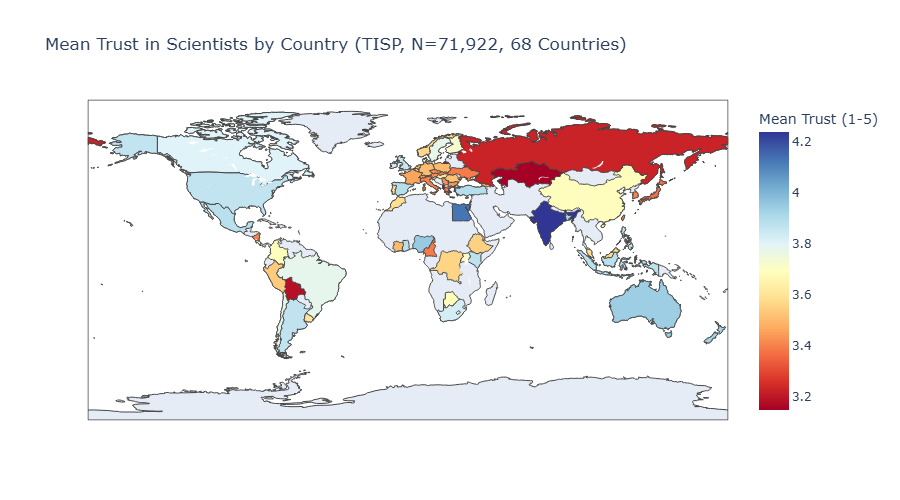

In [5]:
import plotly.express as px
from IPython.display import Image, display

country_means = choropleth(df)
# Inline PNG for notebook rendering; analysis (country-level means) is performed by choropleth() above
_fig = px.choropleth(
    country_means, locations='country', color='mean_trust',
    color_continuous_scale='RdYlBu', locationmode='ISO-3',
    title='Mean Trust in Scientists by Country (TISP, N=71,922, 68 Countries)',
    labels={'mean_trust': 'Mean Trust (1-5)'},
)
_fig.write_image('figures/trust_choropleth_nb.png', width=900, height=500)
display(Image('figures/trust_choropleth_nb.png'))

## 4. ANOVA — Trust by Primary Communication Channel

One-way ANOVA testing whether mean trust in scientists differs significantly across respondents’ primary science information channel.


=== One-way ANOVA: trust ~ primary_channel ===
F = 27.963, p = 1.462e-33

Group means:
                         mean  count
primary_channel                     
Family/Friends       3.565347   3736
Newspapers           3.665038  21497
Online News Sites    3.606484  10960
Other                3.612152   8633
Scientific Journals  3.597087   1415
Social Media         3.578527   8057
Television           3.651938  17585
Boxplot saved to figures/anova_channel_boxplot.png


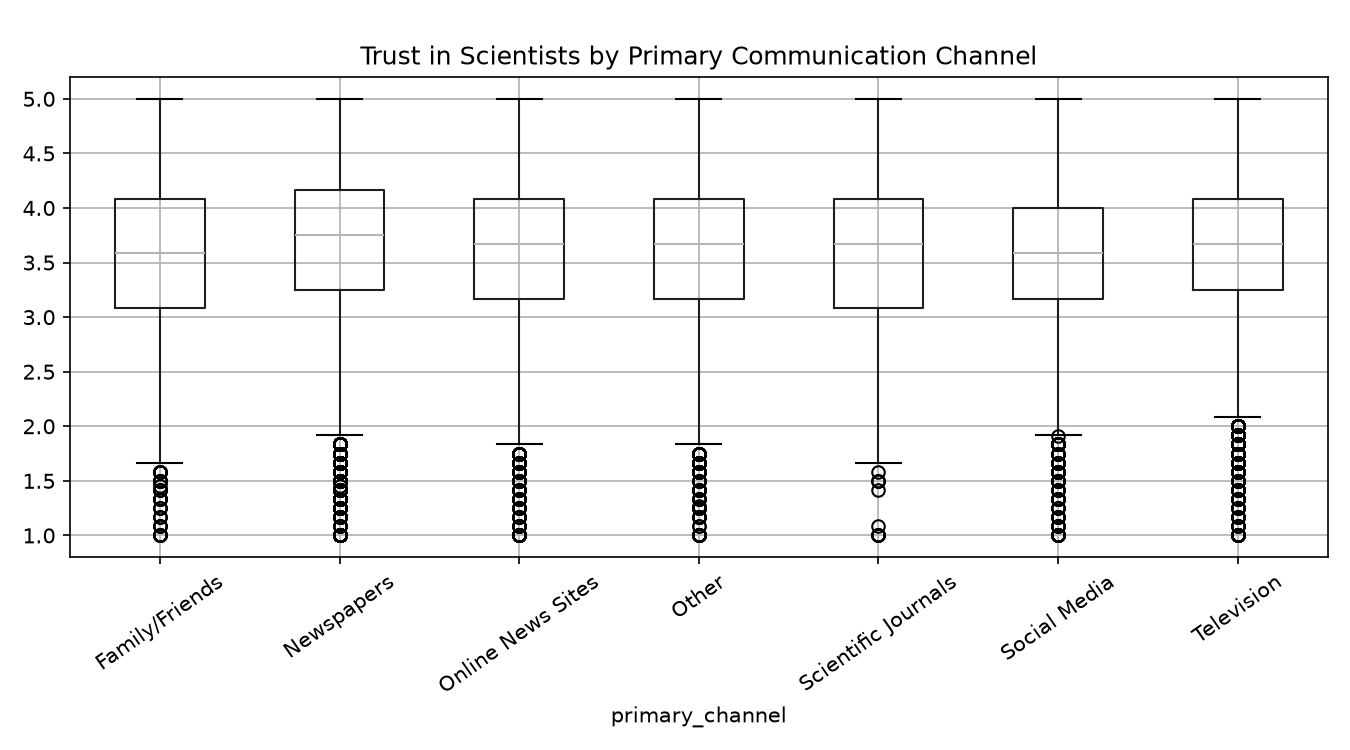

In [6]:
from IPython.display import Image, display

f_stat, p_val = anova_by_channel(df)
display(Image('figures/anova_channel_boxplot.png'))

## Key Findings

| Analysis | Headline result |
|---|---|
| **Multi-level model** | **ICC = 0.105** — 10.5 % of variance in trust in scientists lies between countries, justifying the multi-level approach |
| **SEM mediation** | **Indirect effect = 0.045** — science knowledge partially mediates the positive association between communication frequency and trust |
| **ANOVA** | **F = 27.963, p < 0.001** — trust differs significantly across primary communication channels |
| **Choropleth** | Higher-income regions (Northern/Western Europe, North America, East Asia) show the highest mean trust; sub-Saharan Africa and parts of South Asia show the lowest |

All analyses use the full TISP analytic sample (observations with non-missing trust, comm_freq, and knowledge); see [`code/analysis.py`](../code/analysis.py) for composite-measure derivations.